# GraphRAG: Graph-Enhanced Retrieval-Augmented Generation

## Overview

GraphRAG is an advanced question-answering system that combines the power of graph-based knowledge representation with retrieval-augmented generation. It processes input documents to create a rich knowledge graph, which is then used to enhance the retrieval and generation of answers to user queries.

## How It Works (Step by Step)

1. **Load & Split** — Load a PDF and split it into small text chunks.
2. **Embed & Index** — Turn each chunk into a vector and store them in a FAISS vector store.
3. **Build a Knowledge Graph** — Create a graph where each chunk is a node. Extract concepts from each chunk, then connect nodes that are semantically similar and share concepts.
4. **Query with Graph Traversal** — Given a user question, find the most relevant nodes, then walk the graph (Dijkstra-style) to gather context until the LLM says it has a complete answer.
5. **Visualize** — Show the graph and the path the system took to find the answer.

## Models Used

- **LLM**: `gemma3:12b` via Ollama (local)
- **Embeddings**: `mxbai-embed-large:335m` via Ollama (local)

<div style="text-align: center;">

<img src="./images/graph_rag.svg" alt="graph RAG" style="width:100%; height:auto;">
</div>

---
## Step 0: Install and Import Packages

In [2]:
import networkx as nx
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import heapq

from langchain_ollama import ChatOllama, OllamaEmbeddings

from nltk.stem import WordNetLemmatizer
import nltk
import spacy
from spacy.cli import download

from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

True

---
## Step 1: Initialize the LLM and Embedding Model

We use two Ollama models:
- **ChatOllama** — the language model that reasons, extracts concepts, and answers questions.
- **OllamaEmbeddings** — the model that converts text into numerical vectors for similarity search.

In [3]:
llm = ChatOllama(model="gemma3:12b", temperature=0)
embedding_model = OllamaEmbeddings(model="mxbai-embed-large:335m")

---
## Step 2: Load the PDF Document

We load a PDF file and keep only the first 10 pages to keep processing time manageable.

In [4]:
path = "data/Understanding_Climate_Change.pdf"

loader = PyPDFLoader(path)
documents = loader.load()
documents = documents[:10]

print(f"Loaded {len(documents)} pages")
print(f"First page preview: {documents[0].page_content[:200]}...")

Loaded 10 pages
First page preview: Understanding Climate Change 
Chapter 1: Introduction to Climate Change 
Climate change refers to significant, long-term changes in the global climate. The term 
"global climate" encompasses the plane...


---
## Step 3: Split Documents into Chunks

Large pages are split into smaller overlapping chunks (1000 characters each, with 200-character overlap).
This ensures each chunk is small enough for the LLM to process, while the overlap preserves context across boundaries.

In [5]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splits = text_splitter.split_documents(documents)

print(f"Split {len(documents)} pages into {len(splits)} chunks")
print(f"\nExample chunk (chunk 0):\n{splits[0].page_content[:300]}...")

Split 10 pages into 30 chunks

Example chunk (chunk 0):
Understanding Climate Change 
Chapter 1: Introduction to Climate Change 
Climate change refers to significant, long-term changes in the global climate. The term 
"global climate" encompasses the planet's overall weather patterns, including temperature, 
precipitation, and wind patterns, over an exte...


---
## Step 4: Create the Vector Store (FAISS)

Each chunk is embedded into a vector, and all vectors are stored in a FAISS index.
This lets us quickly find chunks that are similar to a given query.

In [6]:
vector_store = FAISS.from_documents(splits, embedding_model)

print(f"Vector store created with {len(splits)} vectors")

Vector store created with 30 vectors


---
## Step 5: Build the Knowledge Graph — Add Nodes

We create a NetworkX graph where **each node = one text chunk**.
The node stores the chunk's text content.

In [7]:
graph = nx.Graph()

for i, split in enumerate(splits):
    graph.add_node(i, content=split.page_content)

print(f"Added {len(graph.nodes)} nodes to the graph")
print(f"\nNode 0 content preview: {graph.nodes[0]['content'][:200]}...")

Added 30 nodes to the graph

Node 0 content preview: Understanding Climate Change 
Chapter 1: Introduction to Climate Change 
Climate change refers to significant, long-term changes in the global climate. The term 
"global climate" encompasses the plane...


---
## Step 6: Create Embeddings for All Chunks

We embed all chunks so we can compute pairwise similarity between them.
This will be used to decide which nodes should be connected by edges.

In [8]:
texts = [split.page_content for split in splits]
embeddings = embedding_model.embed_documents(texts)

print(f"Created embeddings for {len(embeddings)} chunks")
print(f"Embedding dimension: {len(embeddings[0])}")

Created embeddings for 30 chunks
Embedding dimension: 1024


---
## Step 7: Extract Concepts and Entities from Each Chunk

For each chunk, we extract:
- **Named entities** (people, organizations, places) using spaCy.
- **Key concepts** (abstract ideas like "greenhouse effect") using the LLM.

These concepts are stored on each graph node and will be used to find shared topics between chunks.

In [9]:
# Load spaCy model for named entity recognition
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading spaCy model...")
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# JSON schema that tells the LLM what format to return concepts in
concepts_schema = {
    "title": "Concepts",
    "type": "object",
    "properties": {
        "concepts_list": {
            "type": "array",
            "items": {"type": "string"},
            "description": "List of concepts"
        }
    },
    "required": ["concepts_list"]
}

# Prompt for concept extraction
concept_extraction_prompt = PromptTemplate(
    input_variables=["text"],
    template="Extract key concepts (excluding named entities) from the following text:\n\n{text}\n\nKey concepts:"
)
concept_chain = concept_extraction_prompt | llm.with_structured_output(concepts_schema)

concept_cache = {}

for i, split in enumerate(tqdm(splits, desc="Extracting concepts")):
    content = split.page_content

    if content in concept_cache:
        graph.nodes[i]['concepts'] = concept_cache[content]
        continue

    # Extract named entities with spaCy
    doc = nlp(content)
    named_entities = [ent.text for ent in doc.ents if ent.label_ in ["PERSON", "ORG", "GPE", "WORK_OF_ART"]]

    # Extract general concepts with the LLM
    general_concepts = concept_chain.invoke({"text": content})["concepts_list"]

    # Combine and store
    all_concepts = list(set(named_entities + general_concepts))
    concept_cache[content] = all_concepts
    graph.nodes[i]['concepts'] = all_concepts

print(f"\nExample — Node 0 concepts: {graph.nodes[0]['concepts']}")

Extracting concepts: 100%|████████████████████████████████████████████████████████████████████████| 30/30 [01:08<00:00,  2.27s/it]


Example — Node 0 concepts: ["Earth's orbit", 'Holocene epoch', 'Holocene', 'global climate', 'weather patterns', 'ice age', 'fossil fuels', 'glacial advance and retreat', 'historical climate change', 'modern climate era', 'wind patterns', 'temperature', 'deforestation', 'precipitation', 'human activities', 'solar energy', 'significant long-term changes']


In [10]:
print(f"\nExample — Node 1 concepts: {graph.nodes[1]['concepts']}")


Example — Node 1 concepts: ['climate change', 'emission', 'future trends', 'global temperatures', 'The Intergovernmental Panel on Climate Change', "variations in Earth's orbit", 'greenhouse gases', 'sea levels', 'extreme weather events', 'human activities', 'solar energy', 'Holocene', 'historical record']


---
## Step 8: Add Edges Based on Similarity and Shared Concepts

Two nodes get connected by an edge if their cosine similarity exceeds a threshold (0.8).

The **edge weight** is a blend of:
- **Semantic similarity** (70%) — how similar the embeddings are.
- **Shared concepts** (30%) — what fraction of concepts the two chunks have in common.

Higher weight = stronger connection.

In [10]:
EDGES_THRESHOLD = 0.8
ALPHA = 0.7   # weight for semantic similarity
BETA = 0.3    # weight for shared concepts

similarity_matrix = cosine_similarity(embeddings)
num_nodes = len(graph.nodes)

for node1 in tqdm(range(num_nodes), desc="Adding edges"):
    for node2 in range(node1 + 1, num_nodes):
        sim_score = similarity_matrix[node1][node2]

        if sim_score > EDGES_THRESHOLD:
            concepts1 = set(graph.nodes[node1]['concepts'])
            concepts2 = set(graph.nodes[node2]['concepts'])
            shared = concepts1 & concepts2

            max_possible = min(len(concepts1), len(concepts2))
            norm_shared = len(shared) / max_possible if max_possible > 0 else 0

            edge_weight = ALPHA * sim_score + BETA * norm_shared

            graph.add_edge(node1, node2,
                           weight=edge_weight,
                           similarity=sim_score,
                           shared_concepts=list(shared))

print(f"\nGraph has {len(graph.nodes)} nodes and {len(graph.edges)} edges")

Adding edges: 100%|█| 30/30 [00:00


Graph has 30 nodes and 16 edges


---
## Step 9: Define the Query

Now the knowledge graph is built. Let's ask a question and see how GraphRAG traverses the graph to find the answer.

In [11]:
query = "what is the main cause of climate change?"
print(f"Query: {query}")

Query: what is the main cause of climate change?


---
## Step 10: Retrieve Relevant Documents from the Vector Store

First, we do a standard similarity search to find the top-5 most relevant chunks.
These will be our starting points for graph traversal.

In [12]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 5})
relevant_docs = retriever.invoke(query)

print(f"Retrieved {len(relevant_docs)} relevant documents")
for i, doc in enumerate(relevant_docs):
    print(f"\nDoc {i}: {doc.page_content[:150]}...")

Retrieved 5 relevant documents

Doc 0: Chapter 2: Causes of Climate Change 
Greenhouse Gases 
The primary cause of recent climate change is the increase in greenhouse gases in the 
atmosphe...

Doc 1: Most of these climate changes are attributed to very small variations in Earth's orbit that 
change the amount of solar energy our planet receives. Du...

Doc 2: Understanding Climate Change 
Chapter 1: Introduction to Climate Change 
Climate change refers to significant, long-term changes in the global climate...

Doc 3: Heatwaves can lead to heat-related illnesses and exacerbate existing health conditions. 
Changing Seasons 
Climate change is altering the timing and l...

Doc 4: development of eco-friendly fertilizers and farming techniques is essential for reducing the 
agricultural sector's carbon footprint. 
Chapter 3: Effe...


---
## Step 11: Traverse the Knowledge Graph (Dijkstra-like)

This is the core of GraphRAG. Starting from the most relevant nodes, we walk through the graph:

1. **Priority queue** — nodes are explored in order of connection strength (strongest first).
2. **For each node** — add its content to the accumulated context, then ask the LLM: "Do you have a complete answer yet?"
3. **If not** — explore the node's neighbors, prioritizing those with the strongest edge weights.
4. **Stop** when the LLM says the context is sufficient, or the queue is exhausted.

This is similar to how Dijkstra's shortest path algorithm works, except we're finding the **strongest path** through related information.

In [13]:
# --- Set up the answer-checking chain ---
# This chain asks the LLM whether the accumulated context answers the query
answer_check_schema = {
    "title": "AnswerCheck",
    "type": "object",
    "properties": {
        "is_complete": {
            "type": "boolean",
            "description": "Whether the current context provides a complete answer to the query"
        },
        "answer": {
            "type": "string",
            "description": "The current answer based on the context, if any"
        }
    },
    "required": ["is_complete", "answer"]
}

answer_check_prompt = PromptTemplate(
    input_variables=["query", "context"],
    template=(
        "Given the query: '{query}'\n\n"
        "And the current context:\n{context}\n\n"
        "Does this context provide a complete answer to the query? "
        "If yes, provide the answer. If no, state that the answer is incomplete.\n\n"
        "Is complete answer (Yes/No):\nAnswer (if complete):"
    )
)
answer_check_chain = answer_check_prompt | llm.with_structured_output(answer_check_schema)

# --- Initialize the lemmatizer for concept matching ---
lemmatizer = WordNetLemmatizer()

# --- Initialize traversal state ---
expanded_context = ""
traversal_path = []
visited_concepts = set()
filtered_content = {}
final_answer = ""

priority_queue = []
distances = {}

# --- Seed the priority queue with the most relevant nodes ---
for doc in relevant_docs:
    closest_nodes = vector_store.similarity_search_with_score(doc.page_content, k=1)
    closest_node_content, similarity_score = closest_nodes[0]

    closest_node = next(
        n for n in graph.nodes
        if graph.nodes[n]['content'] == closest_node_content.page_content
    )

    priority = 1 / max(similarity_score, 1e-10)
    heapq.heappush(priority_queue, (priority, closest_node))
    distances[closest_node] = priority

print(f"Priority queue initialized with {len(priority_queue)} starting nodes")

# --- Traverse the graph ---
step = 0
while priority_queue:
    current_priority, current_node = heapq.heappop(priority_queue)

    if current_priority > distances.get(current_node, float('inf')):
        continue

    if current_node not in traversal_path:
        step += 1
        traversal_path.append(current_node)
        node_content = graph.nodes[current_node]['content']
        node_concepts = graph.nodes[current_node]['concepts']

        filtered_content[current_node] = node_content
        expanded_context += "\n" + node_content if expanded_context else node_content

        print(f"\nStep {step} - Node {current_node}:")
        print(f"Content: {node_content[:100]}...")
        print(f"Concepts: {', '.join(node_concepts)}")
        print("-" * 50)

        # Ask the LLM: is the context enough to answer?
        response = answer_check_chain.invoke({"query": query, "context": expanded_context})
        is_complete = response["is_complete"]
        answer = response["answer"]

        if is_complete:
            final_answer = answer
            print("\n>>> Complete answer found! Stopping traversal.")
            break

        # Lemmatize this node's concepts and check for new ones
        node_concepts_set = set(
            ' '.join([lemmatizer.lemmatize(w) for w in c.lower().split()])
            for c in node_concepts
        )

        if not node_concepts_set.issubset(visited_concepts):
            visited_concepts.update(node_concepts_set)

            # Explore neighbors
            for neighbor in graph.neighbors(current_node):
                edge_weight = graph[current_node][neighbor]['weight']
                distance = current_priority + (1 / edge_weight)

                if distance < distances.get(neighbor, float('inf')):
                    distances[neighbor] = distance
                    heapq.heappush(priority_queue, (distance, neighbor))

                    if neighbor not in traversal_path:
                        step += 1
                        traversal_path.append(neighbor)
                        neighbor_content = graph.nodes[neighbor]['content']
                        neighbor_concepts = graph.nodes[neighbor]['concepts']

                        filtered_content[neighbor] = neighbor_content
                        expanded_context += "\n" + neighbor_content

                        print(f"\nStep {step} - Node {neighbor} (neighbor of {current_node}):")
                        print(f"Content: {neighbor_content[:100]}...")
                        print(f"Concepts: {', '.join(neighbor_concepts)}")
                        print("-" * 50)

                        response = answer_check_chain.invoke({"query": query, "context": expanded_context})
                        if response["is_complete"]:
                            final_answer = response["answer"]
                            print("\n>>> Complete answer found! Stopping traversal.")
                            break

                        nbr_concepts_set = set(
                            ' '.join([lemmatizer.lemmatize(w) for w in c.lower().split()])
                            for c in neighbor_concepts
                        )
                        if not nbr_concepts_set.issubset(visited_concepts):
                            visited_concepts.update(nbr_concepts_set)

        if final_answer:
            break

print(f"\nTraversal visited {len(traversal_path)} nodes: {traversal_path}")

Priority queue initialized with 5 starting nodes

Step 1 - Node 0:
Content: Understanding Climate Change 
Chapter 1: Introduction to Climate Change 
Climate change refers to si...
Concepts: global climate, Earth's orbit, precipitation, glacial advance and retreat, fossil fuels, deforestation, solar energy, Holocene epoch, human activities, weather patterns, Holocene, temperature, historical climate change, ice age, modern climate era, significant long-term changes, wind patterns
--------------------------------------------------

Step 2 - Node 1:
Content: Most of these climate changes are attributed to very small variations in Earth's orbit that 
change ...
Concepts: variations in Earth's orbit, extreme weather events, emission, solar energy, greenhouse gases, historical record, global temperatures, climate change, human activities, Holocene, future trends, The Intergovernmental Panel on Climate Change, sea levels
--------------------------------------------------

Step 3 - Node 2:
Con

---
## Step 12: Generate the Final Answer

If the traversal found a complete answer, we use it directly.
Otherwise, we feed all the accumulated context to the LLM and ask it to generate an answer.

In [14]:
if not final_answer:
    print("No complete answer found during traversal. Generating from accumulated context...\n")
    response_prompt = PromptTemplate(
        input_variables=["query", "context"],
        template="Based on the following context, please answer the query.\n\nContext: {context}\n\nQuery: {query}\n\nAnswer:"
    )
    response_chain = response_prompt | llm
    final_answer = response_chain.invoke({"query": query, "context": expanded_context})
else:
    print("Complete answer was found during graph traversal.\n")

print(f"Question: {query}")
print(f"\nAnswer: {final_answer}")

Complete answer was found during graph traversal.

Question: what is the main cause of climate change?

Answer: According to the provided text, the primary cause of recent climate change is the increase in greenhouse gases in the atmosphere. Human activities, particularly the burning of fossil fuels (coal, oil, and natural gas) and deforestation, have significantly contributed to this increase.


---
## Step 13: Visualize the Graph Traversal

The visualization shows:
- **All nodes** (light blue) and edges (colored by weight) in the knowledge graph.
- **Red dashed arrows** showing the traversal path the system took.
- **Green node** = starting node, **Red node** = ending node.

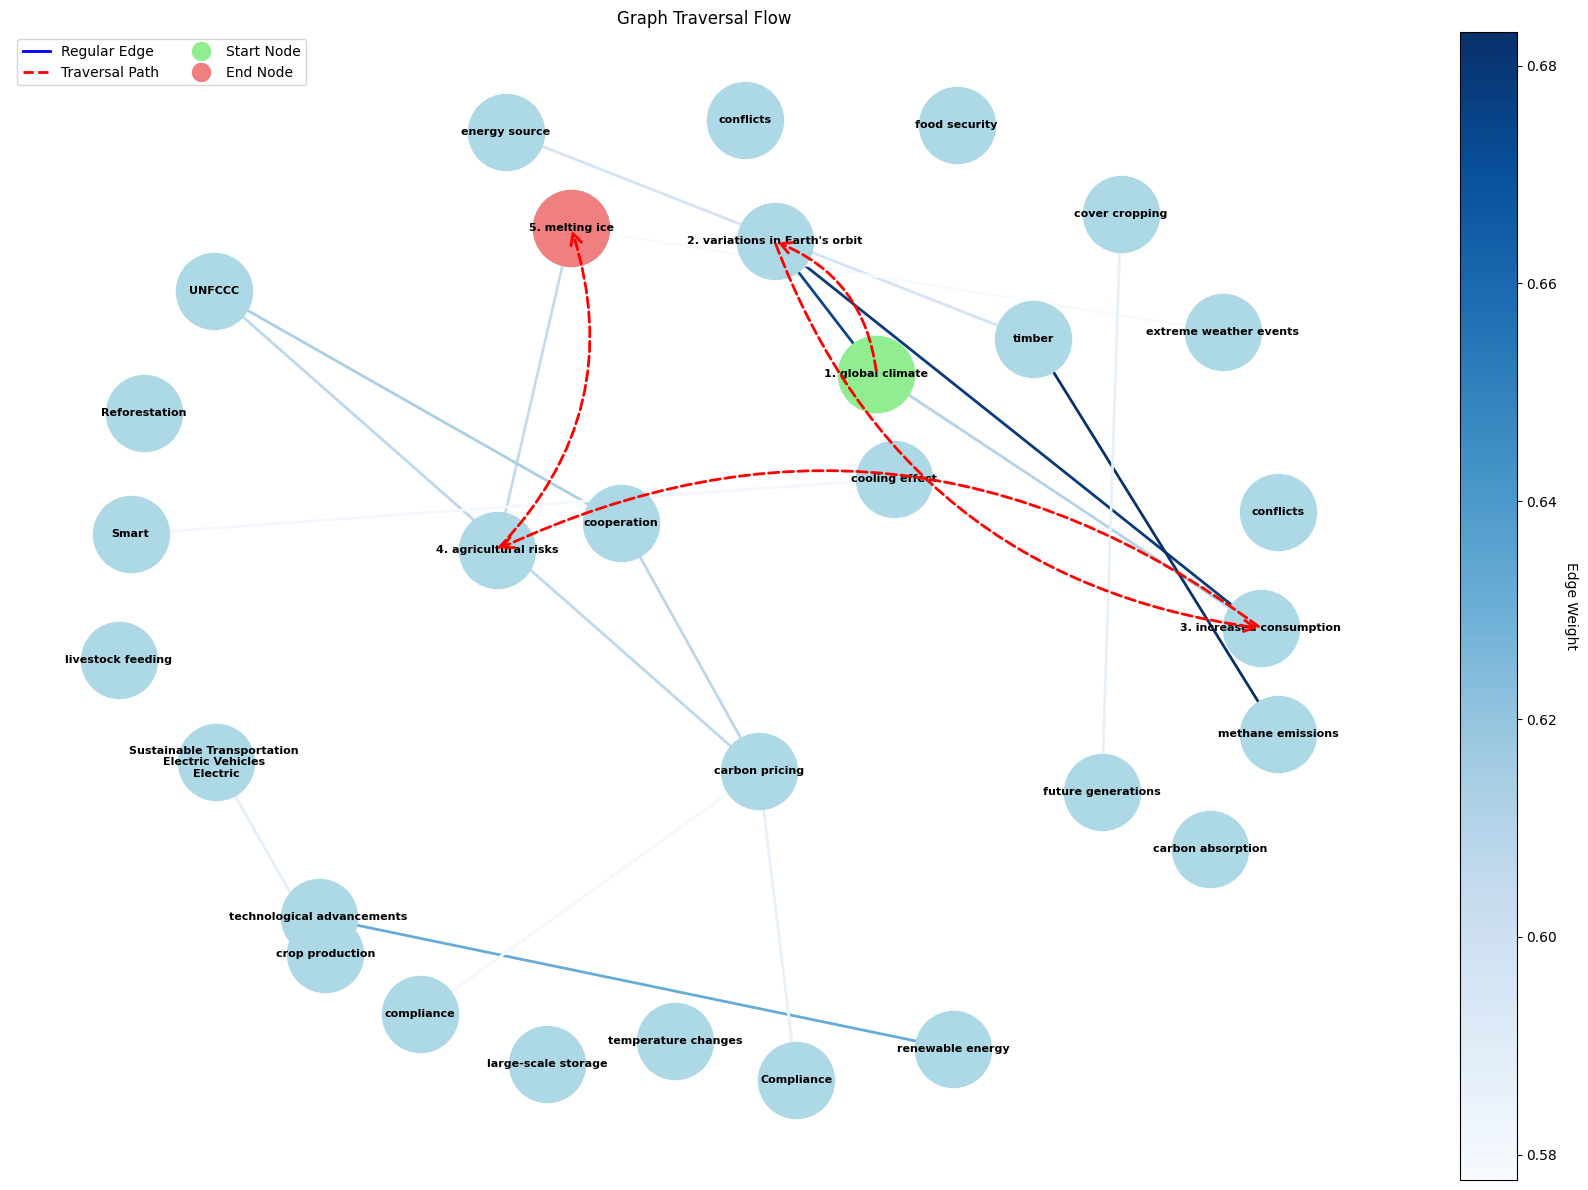

In [15]:
if not traversal_path:
    print("No traversal path to visualize.")
else:
    # Build a directed graph for visualization
    traversal_graph = nx.DiGraph()
    for node in graph.nodes():
        traversal_graph.add_node(node)
    for u, v, data in graph.edges(data=True):
        traversal_graph.add_edge(u, v, **data)

    fig, ax = plt.subplots(figsize=(16, 12))
    pos = nx.spring_layout(traversal_graph, k=1, iterations=50)

    # Draw edges colored by weight
    edges = traversal_graph.edges()
    edge_weights = [traversal_graph[u][v].get('weight', 0.5) for u, v in edges]
    nx.draw_networkx_edges(traversal_graph, pos,
                           edgelist=edges,
                           edge_color=edge_weights,
                           edge_cmap=plt.cm.Blues,
                           width=2, ax=ax)

    # Draw all nodes
    nx.draw_networkx_nodes(traversal_graph, pos,
                           node_color='lightblue',
                           node_size=3000, ax=ax)

    # Draw the traversal path as red dashed arrows
    for i in range(len(traversal_path) - 1):
        start = traversal_path[i]
        end = traversal_path[i + 1]
        arrow = patches.FancyArrowPatch(
            pos[start], pos[end],
            connectionstyle="arc3,rad=0.3",
            color='red', arrowstyle="->",
            mutation_scale=20, linestyle='--',
            linewidth=2, zorder=4
        )
        ax.add_patch(arrow)

    # Labels: traversal nodes get numbered, others show first concept
    labels = {}
    for i, node in enumerate(traversal_path):
        concepts = graph.nodes[node].get('concepts', [])
        labels[node] = f"{i + 1}. {concepts[0] if concepts else ''}"
    for node in traversal_graph.nodes():
        if node not in labels:
            concepts = graph.nodes[node].get('concepts', [])
            labels[node] = concepts[0] if concepts else ''
    nx.draw_networkx_labels(traversal_graph, pos, labels, font_size=8, font_weight="bold", ax=ax)

    # Highlight start (green) and end (red) nodes
    nx.draw_networkx_nodes(traversal_graph, pos,
                           nodelist=[traversal_path[0]],
                           node_color='lightgreen',
                           node_size=3000, ax=ax)
    nx.draw_networkx_nodes(traversal_graph, pos,
                           nodelist=[traversal_path[-1]],
                           node_color='lightcoral',
                           node_size=3000, ax=ax)

    ax.set_title("Graph Traversal Flow")
    ax.axis('off')

    # Colorbar for edge weights
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=min(edge_weights), vmax=max(edge_weights)))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('Edge Weight', rotation=270, labelpad=15)

    # Legend
    legend_handles = [
        plt.Line2D([0], [0], color='blue', linewidth=2, label='Regular Edge'),
        plt.Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Traversal Path'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=15, label='Start Node'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral', markersize=15, label='End Node'),
    ]
    legend = plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(0, 1), ncol=2)
    legend.get_frame().set_alpha(0.8)

    plt.tight_layout()
    plt.show()

---
## Step 14: Inspect the Traversal — What Content Was Visited?

Let's see exactly what chunks the system looked at (in order) to build its answer.

In [16]:
print("Filtered content of visited nodes in order of traversal:\n")
for i, node in enumerate(traversal_path):
    print(f"Step {i + 1} - Node {node}:")
    print(f"{filtered_content.get(node, 'No content')[:200]}...")
    print("-" * 50)

Filtered content of visited nodes in order of traversal:

Step 1 - Node 0:
Understanding Climate Change 
Chapter 1: Introduction to Climate Change 
Climate change refers to significant, long-term changes in the global climate. The term 
"global climate" encompasses the plane...
--------------------------------------------------
Step 2 - Node 1:
Most of these climate changes are attributed to very small variations in Earth's orbit that 
change the amount of solar energy our planet receives. During the Holocene epoch, which 
began at the end o...
--------------------------------------------------
Step 3 - Node 2:
Chapter 2: Causes of Climate Change 
Greenhouse Gases 
The primary cause of recent climate change is the increase in greenhouse gases in the 
atmosphere. Greenhouse gases, such as carbon dioxide (CO2)...
--------------------------------------------------
Step 4 - Node 7:
development of eco-friendly fertilizers and farming techniques is essential for reducing the 
agricultural se